# Dynamic Model in Levels with substitutes

In [1]:
import os
import datasets
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path    

from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score

import doubleml as dml

from utils.utils_data import (
    get_cis,
    generate_basis,
    generate_interactions,
)

from utils.utils_models import (
    iv_model,
    lin_model,
    lin_model_cate,
    summarize_lin_model,
    summarize_dml,
    chi2_test,
    predict_cate,
)

# Get a colorblind-friendly palette
palette = sns.color_palette("colorblind")

confidence_level = 0.9
ci_level_name, ci_names = get_cis(confidence_level)

output_dir = "../../output/A3_dimensionality_reduction_via_NN/output_evaluation"
Path(output_dir).mkdir(parents=True, exist_ok=True)

Confidence Level: 90.0%


In [3]:
txt_only = False
include_embeddings = True
dataframe_name = f"dataset_txt_only_{txt_only}_embeddings_{include_embeddings}_shared_weights"
df_full_train = pd.read_csv(f"../../data/A3_dimensionality_reduction_via_NN/{dataframe_name}_train.zip")
df_full_val = pd.read_csv(f"../../data/A3_dimensionality_reduction_via_NN/{dataframe_name}_val.zip")

columns_to_drop = [
    'Q_t-2',
    'P_bb_t-2',
    'REVIEW_COUNT_t-2',
    'RATING_t-2',
]

df_full_train = df_full_train.drop(columns=columns_to_drop)
df_full_val = df_full_val.drop(columns=columns_to_drop)

df_full_train = df_full_train.dropna()
df_full_val = df_full_val.dropna()

dummy_subcat_names = [category for category in df_full_val['subcat_aggregated'].unique()]
all_time_steps = sorted([str(date) for date in df_full_val['date'].unique()])

print(f"Dummy subcat names: {dummy_subcat_names}")
print(f"All time steps: {all_time_steps}")
df_full_val.columns

Dummy subcat names: ['Residual', 'Cars & Race Cars', 'Trains & Trams', 'Train Sets', 'Trucks', 'Tractors', 'Race Tracks', 'Airplanes', 'Motor Vehicles', 'Vehicle Playsets', 'Skateboards']
All time steps: ['2023-02-27', '2023-03-27', '2023-04-24', '2023-05-22', '2023-06-19', '2023-07-17', '2023-08-14', '2023-09-11', '2023-10-09', '2023-11-06', '2023-12-04', '2024-01-01', '2024-01-29']


Index(['ASIN', 'date', 'index', 'Q_t', 'PRICE', 'P_bb_t', 'text', 'window',
       'REVIEW_COUNT', 'RATING', 'New Offer Count: Current',
       'Count of retrieved live offers: New, FBA',
       'Count of retrieved live offers: New, FBM',
       'Lightning Deals: Upcoming Deal', 'Buy Box: Is FBA',
       'subcat_aggregated', 'date_t', 'Airplanes', 'Cars & Race Cars',
       'Motor Vehicles', 'Race Tracks', 'Residual', 'Skateboards', 'Tractors',
       'Train Sets', 'Trains & Trams', 'Trucks', 'Vehicle Playsets',
       '2023-01-30', '2023-02-27', '2023-03-27', '2023-04-24', '2023-05-22',
       '2023-06-19', '2023-07-17', '2023-08-14', '2023-09-11', '2023-10-09',
       '2023-11-06', '2023-12-04', '2024-01-01', '2024-01-29', 'Airplanes.1',
       'Cars & Race Cars.1', 'Motor Vehicles.1', 'Race Tracks.1', 'Residual.1',
       'Skateboards.1', 'Tractors.1', 'Train Sets.1', 'Trains & Trams.1',
       'Trucks.1', 'Vehicle Playsets.1', 'pred_ml_l', 'pred_ml_m',
       'embedding_feature_0',

In [4]:
df_full_val.isna().sum()

ASIN                0
date                0
index               0
Q_t                 0
PRICE               0
                   ..
P_bb_t-1            0
REVIEW_COUNT_t-1    0
RATING_t-1          0
Delta_Q_t           0
Delta_P_bb_t        0
Length: 71, dtype: int64

In [5]:
df_full_train["date"].unique()

array(['2023-02-27', '2023-03-27', '2023-04-24', '2023-05-22',
       '2023-06-19', '2023-07-17', '2023-08-14', '2023-09-11',
       '2023-10-09', '2023-11-06', '2023-12-04', '2024-01-01',
       '2024-01-29'], dtype=object)

In [6]:
df_full_val["date"].unique()

array(['2023-02-27', '2023-03-27', '2023-04-24', '2023-05-22',
       '2023-06-19', '2023-07-17', '2023-08-14', '2023-09-11',
       '2023-10-09', '2023-11-06', '2023-12-04', '2024-01-01',
       '2024-01-29'], dtype=object)

In [7]:
df_full_train["ASIN"].nunique()

3717

In [8]:
df_full_val["ASIN"].nunique()

3708

In [9]:
from datetime import datetime

date_objects = [datetime.strptime(date, '%Y-%m-%d') for date in all_time_steps]

# Calculate the difference in days between consecutive dates
date_differences = [(date_objects[i+1] - date_objects[i]).days for i in range(len(date_objects) - 1)]

# Print the differences
print(date_differences)

[28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28]


## Variable Names

In [10]:
n_lags = 1

outcome = ["Q_t"]
base_treatment = ["P_bb_t"]
lag_1_vars = ["Q_t-1", "P_bb_t-1"]

dummy_time_steps = all_time_steps[n_lags:]

all_dummy_controls = (
    dummy_subcat_names
    + dummy_time_steps
    + [
        "Lightning Deals: Upcoming Deal",
        "Buy Box: Is FBA",
    ]
)
dummy_baselines = [dummy_time_steps[0], "Residual"]
dummy_time_steps_wo_baseline = [t for t in dummy_time_steps if t not in dummy_baselines]
dummy_controls = [t for t in all_dummy_controls if t not in dummy_baselines]

cont_controls = [
    "RATING_t-1",
    "REVIEW_COUNT_t-1",
    "New Offer Count: Current",
    "Count of retrieved live offers: New, FBA",
    "Count of retrieved live offers: New, FBM",
]

add_controls_to_scale = [
    "RATING",
    "REVIEW_COUNT",
]

controls_emb = ['embedding_feature_0', 'embedding_feature_1', 'embedding_feature_2',
       'embedding_feature_3', 'embedding_feature_4']

all_control_features = controls_emb
controls_similarities = all_control_features
controls_similarities_non_zero = controls_similarities

embeddings = [f"emb_{i}" for i in range(5)]

controls_to_scale = cont_controls + add_controls_to_scale

additional_controls = (
    cont_controls
    + dummy_controls
)

## Interactions & CATE Basis

In [11]:
basis_vars = controls_similarities + lag_1_vars
df_basis, column_transformer, column_dict = generate_basis(
    df=df_full_val,
    cols_without_scaling=controls_similarities,
    cols_to_scale=lag_1_vars,
    degree=1
)
df_basis.head()

,intercept,Q_t-1,P_bb_t-1,embedding_feature_0,embedding_feature_1,embedding_feature_2,embedding_feature_3,embedding_feature_4
0,1.0,0.305280,0.463601,0.031347,0.014870,0.081420,-0.000508,0.035535
1,1.0,0.272505,0.653600,0.033163,0.016355,0.068650,-0.000415,0.037952
2,1.0,0.036240,0.687961,0.033476,0.016584,0.066604,-0.000398,0.038318
3,1.0,0.025283,0.636881,0.032902,0.015976,0.071955,-0.000435,0.037443
4,1.0,-0.051370,0.556816,0.036109,0.018395,0.051093,-0.000275,0.041751


In [12]:
df_interact_val, interaction_vars = generate_interactions(
    df=df_full_val,
    df_basis=df_basis,
    cols_to_interact=["Q_t-1", "P_bb_t-1"])

print(f"Interactions: {interaction_vars}")
df_interact_val.columns

Interactions: ['interaction_Q_t-1_intercept', 'interaction_Q_t-1_Q_t-1', 'interaction_Q_t-1_P_bb_t-1', 'interaction_Q_t-1_embedding_feature_0', 'interaction_Q_t-1_embedding_feature_1', 'interaction_Q_t-1_embedding_feature_2', 'interaction_Q_t-1_embedding_feature_3', 'interaction_Q_t-1_embedding_feature_4', 'interaction_P_bb_t-1_intercept', 'interaction_P_bb_t-1_Q_t-1', 'interaction_P_bb_t-1_P_bb_t-1', 'interaction_P_bb_t-1_embedding_feature_0', 'interaction_P_bb_t-1_embedding_feature_1', 'interaction_P_bb_t-1_embedding_feature_2', 'interaction_P_bb_t-1_embedding_feature_3', 'interaction_P_bb_t-1_embedding_feature_4']


Index(['ASIN', 'date', 'index', 'Q_t', 'PRICE', 'P_bb_t', 'text', 'window',
       'REVIEW_COUNT', 'RATING', 'New Offer Count: Current',
       'Count of retrieved live offers: New, FBA',
       'Count of retrieved live offers: New, FBM',
       'Lightning Deals: Upcoming Deal', 'Buy Box: Is FBA',
       'subcat_aggregated', 'date_t', 'Airplanes', 'Cars & Race Cars',
       'Motor Vehicles', 'Race Tracks', 'Residual', 'Skateboards', 'Tractors',
       'Train Sets', 'Trains & Trams', 'Trucks', 'Vehicle Playsets',
       '2023-01-30', '2023-02-27', '2023-03-27', '2023-04-24', '2023-05-22',
       '2023-06-19', '2023-07-17', '2023-08-14', '2023-09-11', '2023-10-09',
       '2023-11-06', '2023-12-04', '2024-01-01', '2024-01-29', 'Airplanes.1',
       'Cars & Race Cars.1', 'Motor Vehicles.1', 'Race Tracks.1', 'Residual.1',
       'Skateboards.1', 'Tractors.1', 'Train Sets.1', 'Trains & Trams.1',
       'Trucks.1', 'Vehicle Playsets.1', 'pred_ml_l', 'pred_ml_m',
       'embedding_feature_0',

## Average Effect

In [13]:
df_dynamic = df_interact_val.copy()

### Linear Models

In [14]:
def estimate_linear_model(controls):
    model = lin_model(
        df=df_dynamic,
        outcome=outcome,
        treatments=base_treatment,
        controls=controls,
        level=confidence_level,
        cov_type="cluster",
        cov_kwds={"groups": df_dynamic["ASIN"]},
    )
    return model

In [15]:
estimate_linear_model(controls=[])

Adjusted R^2: 0.0027
          coef  std err        t  P>|t|   [5.0%  95.0%]
const  -10.756    0.104 -103.858  0.000 -10.926 -10.586
P_bb_t  -0.111    0.033   -3.384  0.001  -0.164  -0.057


,lower,upper,coef
P_bb_t,-0.164462,-0.056884,-0.110673


In [16]:
ci_linear_base_lagged = estimate_linear_model(controls=lag_1_vars)

Adjusted R^2: 0.8835
           coef  std err        t  P>|t|  [5.0%  95.0%]
const    -0.677    0.034  -19.935    0.0 -0.733  -0.621
P_bb_t   -0.690    0.040  -17.248    0.0 -0.756  -0.624
Q_t-1     0.936    0.003  321.411    0.0  0.931   0.941
P_bb_t-1  0.678    0.040   16.995    0.0  0.613   0.744


In [17]:
ci_linear_embeddings = estimate_linear_model(controls=lag_1_vars + embeddings)

Adjusted R^2: 0.8857
           coef  std err        t  P>|t|  [5.0%  95.0%]
const    -2.192    0.941   -2.330  0.020 -3.739  -0.644
P_bb_t   -0.689    0.040  -17.412  0.000 -0.755  -0.624
Q_t-1     0.897    0.004  204.893  0.000  0.889   0.904
P_bb_t-1  0.630    0.040   15.908  0.000  0.564   0.695
emb_0    -0.144    0.126   -1.143  0.253 -0.352   0.063
emb_1     0.337    0.175    1.928  0.054  0.049   0.624
emb_2    -0.185    0.014  -13.082  0.000 -0.208  -0.162
emb_3    -1.959    0.966   -2.028  0.043 -3.548  -0.370
emb_4     0.193    0.202    0.956  0.339 -0.139   0.525


In [18]:
ci_linear_base_lagged_add_controls = estimate_linear_model(controls=lag_1_vars + additional_controls)

Adjusted R^2: 0.8929
                                           coef  std err        t  P>|t|  \
const                                    -0.962    0.051  -18.978  0.000   
P_bb_t                                   -0.746    0.039  -18.956  0.000   
Q_t-1                                     0.925    0.003  279.493  0.000   
P_bb_t-1                                  0.722    0.039   18.383  0.000   
RATING_t-1                                0.030    0.007    4.621  0.000   
REVIEW_COUNT_t-1                          0.000    0.000    8.670  0.000   
New Offer Count: Current                 -0.001    0.001   -1.625  0.104   
Count of retrieved live offers: New, FBA  0.005    0.001    3.398  0.001   
Count of retrieved live offers: New, FBM -0.004    0.001   -3.797  0.000   
Cars & Race Cars                          0.020    0.006    3.371  0.001   
Trains & Trams                            0.052    0.014    3.754  0.000   
Train Sets                                0.032    0.008    4.069  

In [19]:
ci_linear_base_lagged_add_controls_emb = estimate_linear_model(controls=lag_1_vars + additional_controls + embeddings)

Adjusted R^2: 0.8941
                                           coef  std err        t  P>|t|  \
const                                    -2.834    0.950   -2.983  0.003   
P_bb_t                                   -0.746    0.039  -19.087  0.000   
Q_t-1                                     0.901    0.004  204.727  0.000   
P_bb_t-1                                  0.690    0.039   17.668  0.000   
RATING_t-1                                0.026    0.007    3.887  0.000   
REVIEW_COUNT_t-1                          0.000    0.000    1.419  0.156   
New Offer Count: Current                 -0.001    0.001   -1.121  0.262   
Count of retrieved live offers: New, FBA  0.002    0.002    1.598  0.110   
Count of retrieved live offers: New, FBM -0.001    0.001   -0.566  0.572   
Cars & Race Cars                          0.017    0.006    2.644  0.008   
Trains & Trams                            0.032    0.015    2.153  0.031   
Train Sets                                0.023    0.009    2.651  

In [20]:
ci_linear_base_lagged_add_controls_sim = estimate_linear_model(controls=lag_1_vars + controls_similarities + additional_controls)

Adjusted R^2: 0.8941
                                           coef  std err        t  P>|t|  \
const                                    -2.834    0.950   -2.983  0.003   
P_bb_t                                   -0.746    0.039  -19.087  0.000   
Q_t-1                                     0.901    0.004  204.727  0.000   
P_bb_t-1                                  0.690    0.039   17.668  0.000   
embedding_feature_0                      -0.012    0.129   -0.092  0.927   
embedding_feature_1                       0.292    0.172    1.697  0.090   
embedding_feature_2                      -0.167    0.014  -11.705  0.000   
embedding_feature_3                      -2.413    0.977   -2.470  0.013   
embedding_feature_4                       0.090    0.203    0.445  0.656   
RATING_t-1                                0.026    0.007    3.887  0.000   
REVIEW_COUNT_t-1                          0.000    0.000    1.419  0.156   
New Offer Count: Current                 -0.001    0.001   -1.121  

In [21]:
ci_linear_interactions = estimate_linear_model(controls=interaction_vars + controls_similarities + additional_controls)

Adjusted R^2: 0.8945
                                            coef  std err       t  P>|t|  \
const                                    -11.374    8.929  -1.274  0.203   
P_bb_t                                    -0.750    0.039 -19.152  0.000   
interaction_Q_t-1_intercept                0.621    0.037  16.659  0.000   
interaction_Q_t-1_Q_t-1                   -0.011    0.005  -2.199  0.028   
interaction_Q_t-1_P_bb_t-1                -0.049    0.002 -21.857  0.000   
interaction_Q_t-1_embedding_feature_0      0.001    0.137   0.005  0.996   
interaction_Q_t-1_embedding_feature_1      0.231    0.179   1.294  0.196   
interaction_Q_t-1_embedding_feature_2     -0.013    0.016  -0.792  0.429   
interaction_Q_t-1_embedding_feature_3     -1.522    0.839  -1.814  0.070   
interaction_Q_t-1_embedding_feature_4     -0.128    0.201  -0.637  0.524   
interaction_P_bb_t-1_intercept            -0.157    0.011 -14.590  0.000   
interaction_P_bb_t-1_Q_t-1                 0.084    0.014   5.927  

In [22]:
ci_linear_base_lagged['model'] = 'Linear lagged'
ci_linear_embeddings['model'] = 'Linear lagged_and_embeddings'
ci_linear_base_lagged_add_controls['model'] = 'Linear lagged_and_add_controls'
ci_linear_base_lagged_add_controls_emb['model'] = 'Linear lagged_and_add_controls_and_emb'
ci_linear_base_lagged_add_controls_sim['model'] = 'Linear lagged_and_add_controls_and_ReLU_features'
ci_linear_interactions['model'] = 'Linear interactions'

df_base = pd.concat([
    ci_linear_base_lagged,
    ci_linear_embeddings,
    ci_linear_base_lagged_add_controls,
    ci_linear_base_lagged_add_controls_emb,
    ci_linear_base_lagged_add_controls_sim
], ignore_index=True)

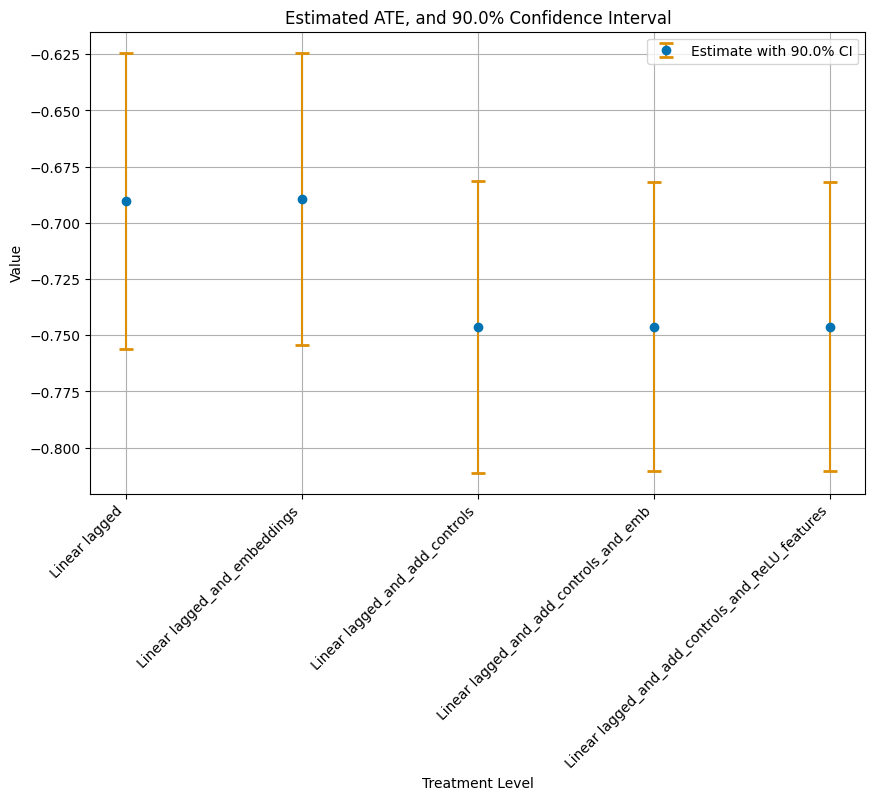

In [23]:

# Plotting
plt.figure(figsize=(10, 6))
# Plot Estimate with CI
plt.errorbar(df_base['model'], df_base['coef'],
             yerr=[df_base['coef'] - df_base['lower'], df_base['upper'] - df_base['coef']],
             fmt='o', capsize=5, capthick=2, ecolor=palette[1], color=palette[0], label=f'Estimate with {round(confidence_level*100, 1)}% CI', zorder=2)

plt.title(f'Estimated ATE, and {round(confidence_level*100, 1)}% Confidence Interval')
plt.xlabel('Treatment Level')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, f'linear_ate_estimates.png'))
plt.show()

In [24]:
df_base

,lower,upper,coef,model
0,-0.756093,-0.624438,-0.690266,Linear lagged
1,-0.754550,-0.624293,-0.689421,Linear lagged_and_embeddings
2,-0.811127,-0.681600,-0.746364,Linear lagged_and_add_controls
3,-0.810624,-0.681994,-0.746309,Linear lagged_and_add_controls_and_emb
4,-0.810624,-0.681994,-0.746309,Linear lagged_and_add_controls_and_ReLU_features


### DML Models

In [25]:
ml_g = LGBMRegressor(n_estimators=500, lr=0.02, random_state=42, verbose=-1)
ml_m = LGBMRegressor(n_estimators=500, lr=0.02, random_state=42, verbose=-1)

def r2(y_true, y_pred):
    subset = np.logical_not(np.isnan(y_true))
    return r2_score(y_true[subset], y_pred[subset])

def estimate_dml_model(controls):
    tab_dml_data = dml.DoubleMLClusterData(
        df_dynamic,
        y_col=outcome[0],
        d_cols=base_treatment,
        x_cols=controls,
        cluster_cols="ASIN")

    np.random.seed(3141)
    tab_dml_obj = dml.DoubleMLPLR(tab_dml_data, ml_g, ml_m)
    tab_dml_obj.fit()

    tab_summary_df = summarize_dml(tab_dml_obj, level=confidence_level)
    ci_tab_dml = tab_summary_df[ci_names + ['coef']]
    ci_tab_dml.columns = ['lower', 'upper', 'coef']

    r2_scores = tab_dml_obj.evaluate_learners(metric=r2)
    print(f"R2 Outcome: {round(r2_scores['ml_l'][0, 0],4)} R2 Treatment: {round(r2_scores['ml_m'][0, 0],4)}\n")

    return tab_dml_obj, ci_tab_dml

In [26]:
tab_dml_obj_embeddings, ci_tab_dml_embeddings = estimate_dml_model(controls=lag_1_vars + embeddings)

C:\Users\Work\AppData\Local\Temp\ipykernel_34360\3595506967.py:9: FutureWarning: DoubleMLClusterData is deprecated and will be removed with version 0.12.0. Use DoubleMLData with cluster_cols instead.
  tab_dml_data = dml.DoubleMLClusterData(


c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.w

         coef  std err       t  P>|t|   5.0%  95.0%
P_bb_t -0.628    0.044 -14.109    0.0 -0.701 -0.554
R2 Outcome: 0.8733 R2 Treatment: 0.9749



In [27]:
tab_dml_obj_add_controls, ci_tab_dml_add_controls = estimate_dml_model(controls=lag_1_vars + additional_controls)

C:\Users\Work\AppData\Local\Temp\ipykernel_34360\3595506967.py:9: FutureWarning: DoubleMLClusterData is deprecated and will be removed with version 0.12.0. Use DoubleMLData with cluster_cols instead.
  tab_dml_data = dml.DoubleMLClusterData(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor w

        coef  std err       t  P>|t|   5.0%  95.0%
P_bb_t -0.69    0.041 -16.812    0.0 -0.758 -0.623
R2 Outcome: 0.8991 R2 Treatment: 0.9775



In [28]:
tab_dml_obj_embeddings_add_controls, ci_tab_dml_embeddings_add_controls = estimate_dml_model(controls=lag_1_vars + embeddings + additional_controls)

C:\Users\Work\AppData\Local\Temp\ipykernel_34360\3595506967.py:9: FutureWarning: DoubleMLClusterData is deprecated and will be removed with version 0.12.0. Use DoubleMLData with cluster_cols instead.
  tab_dml_data = dml.DoubleMLClusterData(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor w

         coef  std err       t  P>|t|   5.0%  95.0%
P_bb_t -0.709    0.042 -17.036    0.0 -0.777  -0.64
R2 Outcome: 0.8982 R2 Treatment: 0.977



In [29]:
tab_dml_obj_sim_add_controls, ci_tab_dml_sim_add_controls = estimate_dml_model(controls=lag_1_vars + controls_similarities + additional_controls)

C:\Users\Work\AppData\Local\Temp\ipykernel_34360\3595506967.py:9: FutureWarning: DoubleMLClusterData is deprecated and will be removed with version 0.12.0. Use DoubleMLData with cluster_cols instead.
  tab_dml_data = dml.DoubleMLClusterData(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor w

         coef  std err       t  P>|t|   5.0%  95.0%
P_bb_t -0.709    0.042 -17.036    0.0 -0.777  -0.64
R2 Outcome: 0.8982 R2 Treatment: 0.977



### Visualization

In [30]:
ci_tab_dml_embeddings['model'] = 'plr_embeddings'
ci_tab_dml_add_controls['model'] = 'plr_add_controls'
ci_tab_dml_embeddings_add_controls['model'] = 'plr_embeddings_add_controls'
ci_tab_dml_sim_add_controls['model'] = 'plr_ReLU_feat_add_controls'


df_averages = pd.concat([
    ci_tab_dml_embeddings,
    ci_tab_dml_add_controls,
    ci_tab_dml_embeddings_add_controls,
    ci_tab_dml_sim_add_controls,
], ignore_index=True)

In [31]:
df_averages

,lower,upper,coef,model
0,-0.700794,-0.554459,-0.627627,plr_embeddings
1,-0.757775,-0.622714,-0.690244,plr_add_controls
2,-0.777045,-0.640209,-0.708627,plr_embeddings_add_controls
3,-0.777045,-0.640209,-0.708627,plr_ReLU_feat_add_controls


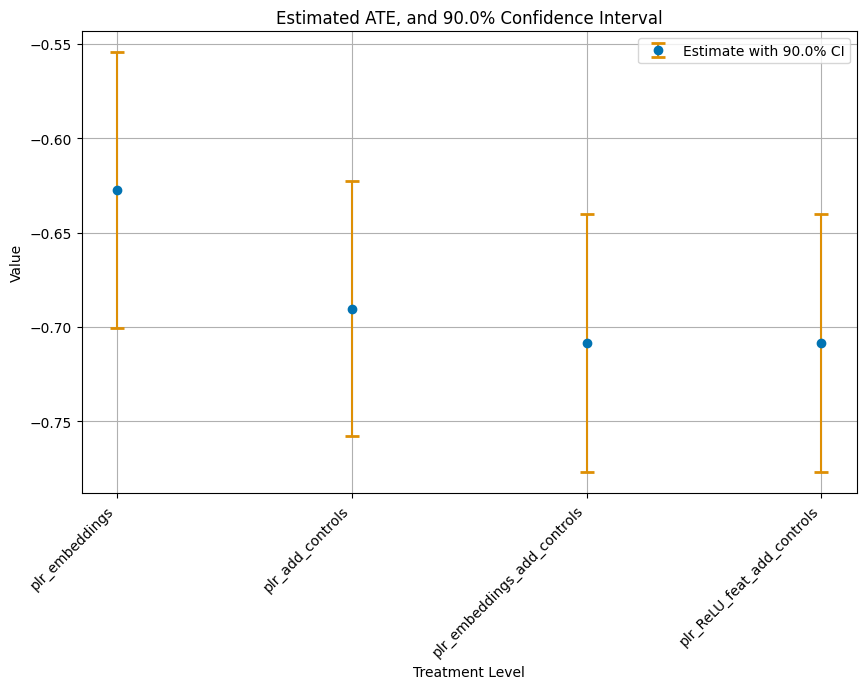

In [32]:

# Plotting
plt.figure(figsize=(10, 6))
# Plot Estimate with CI
plt.errorbar(df_averages['model'], df_averages['coef'],
             yerr=[df_averages['coef'] - df_averages['lower'], df_averages['upper'] - df_averages['coef']],
             fmt='o', capsize=5, capthick=2, ecolor=palette[1], color=palette[0], label=f'Estimate with {round(confidence_level*100, 1)}% CI', zorder=2)

plt.title(f'Estimated ATE, and {round(confidence_level*100, 1)}% Confidence Interval')
plt.xlabel('Treatment Level')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, f'plr_ate_estimates.png'))
plt.show()

## GATEs

In [33]:
df_dynamic[controls_similarities]

,embedding_feature_0,embedding_feature_1,embedding_feature_2,embedding_feature_3,embedding_feature_4
0,-0.752513,-0.741140,2.527550,-0.996829,-0.667598
1,-0.750696,-0.739655,2.514781,-0.996736,-0.665181
2,-0.750383,-0.739427,2.512734,-0.996719,-0.664815
3,-0.750957,-0.740034,2.518085,-0.996757,-0.665691
4,-0.747751,-0.737616,2.497223,-0.996596,-0.661382
...,...,...,...,...,...
38036,-0.896693,-0.820705,2.442290,-0.999179,-0.822928
38037,-0.728175,-0.754875,2.959251,-0.997891,-0.657210
38038,-0.707723,-0.743520,2.916839,-0.997498,-0.636351
38039,-0.558166,-0.656854,2.614621,-0.992996,-0.518061


0
embedding_feature_2    38041
dtype: int64


c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\matplotlib\cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


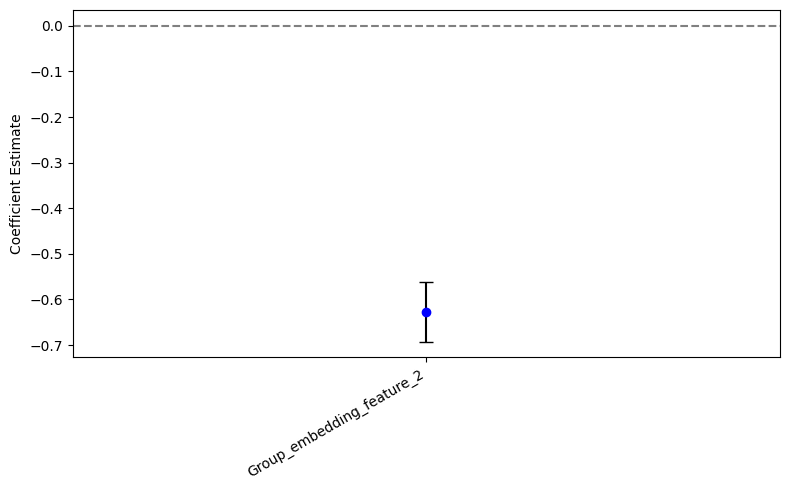

In [34]:
groups = pd.DataFrame(df_dynamic[controls_similarities].idxmax(axis=1))

print(groups.groupby(0).size())
gates_0 = tab_dml_obj_embeddings.gate(groups)
gates_0_summ = gates_0.summary
gates_0_summ["err_lower"] = gates_0_summ["coef"] - gates_0_summ["[0.025"]
gates_0_summ["err_upper"] = gates_0_summ["0.975]"] - gates_0_summ["coef"]

# Positions on the x-axis
x_vals = range(len(gates_0_summ))

plt.figure(figsize=(8, 5))
plt.errorbar(
    x=x_vals,
    y=gates_0_summ["coef"],
    yerr=[gates_0_summ["err_lower"], gates_0_summ["err_upper"]],
    fmt='o',
    capsize=5,
    color='blue',
    ecolor='black'
)

# Draw a zero line for reference
plt.axhline(y=0, color='gray', linestyle='--')

# Customizing x-axis labels
plt.xticks(ticks=x_vals, labels=[gr.replace("outcome_feature", "") for gr in gates_0_summ.index], rotation=30, ha='right')
plt.ylabel("Coefficient Estimate")
plt.tight_layout()
plt.show()

## CATEs

In [35]:
uniform_ci = True  # False | True

In [36]:
cate_controls = lag_1_vars + embeddings + additional_controls
cate_controls_interactions = cate_controls + interaction_vars

plr_obj = tab_dml_obj_embeddings_add_controls

In [37]:
# clear RAM to avoid OOM issues
import gc
gc.collect()

3498

In [38]:
cate_kwargs_val = {
    'cov_type': 'cluster',
    'cov_kwds': {'groups': df_dynamic["ASIN"]}
}

cate_models_polynomial = {
    'Linear Specification': None,
    'Linear Specification (Interactions)': None,
    'PLR Specification': None,
}

# Linear Models
cate_models_polynomial['Linear Specification'] = lin_model_cate(
    df=df_dynamic,
    outcome=outcome,
    basis=df_basis,
    treatment=base_treatment,
    controls=cate_controls,
    **cate_kwargs_val,
)

print(f"\nLinear Specification")
df_specification_1 = summarize_lin_model(cate_models_polynomial['Linear Specification'], level=confidence_level)
print("=" * 80)#

cate_models_polynomial['Linear Specification (Interactions)'] = lin_model_cate(
    df=df_dynamic,
    outcome=outcome,
    basis=df_basis,
    treatment=base_treatment,
    controls=cate_controls_interactions,
    **cate_kwargs_val,
)

print(f"\nLinear specification with interactions")
df_specification_2 = summarize_lin_model(cate_models_polynomial['Linear Specification (Interactions)'], level=confidence_level)
print("=" * 80)

# tabular DML model
cate_models_polynomial['PLR Specification'] = plr_obj.cate(
    df_basis, **cate_kwargs_val
)

print(f"\nTabular DML PLR Specification")
df_specification_3 = summarize_lin_model(
    cate_models_polynomial['PLR Specification'].blp_model, level=confidence_level
)
print("=" * 80)



Linear Specification
                      coef  std err       t  P>|t|    5.0%   95.0%
intercept           -0.754    0.040 -19.039  0.000  -0.819  -0.689
Q_t-1               -0.199    0.053  -3.717  0.000  -0.286  -0.111
P_bb_t-1            -0.013    0.048  -0.265  0.791  -0.091   0.066
embedding_feature_0 -2.941    2.648  -1.111  0.267  -7.297   1.415
embedding_feature_1 -5.369    3.270  -1.642  0.101 -10.748   0.009
embedding_feature_2  0.046    0.160   0.290  0.772  -0.217   0.310
embedding_feature_3  4.553    7.873   0.578  0.563  -8.396  17.503
embedding_feature_4  5.519    4.008   1.377  0.169  -1.074  12.112

Linear specification with interactions
                      coef  std err       t  P>|t|    5.0%   95.0%
intercept           -0.759    0.040 -19.107  0.000  -0.824  -0.694
Q_t-1               -0.210    0.054  -3.918  0.000  -0.298  -0.122
P_bb_t-1            -0.027    0.049  -0.565  0.572  -0.108   0.053
embedding_feature_0 -3.045    2.659  -1.145  0.252  -7.419   1.328


In [39]:
cate_models_polynomial['Linear Specification (Interactions)'].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.026
Model:                            OLS   Adj. R-squared (uncentered):              0.026
Method:                 Least Squares   F-statistic:                              52.42
Date:                Fri, 16 Jan 2026   Prob (F-statistic):                    6.00e-81
Time:                        16:32:40   Log-Likelihood:                         -21622.
No. Observations:               38041   AIC:                                  4.326e+04
Df Residuals:                   38033   BIC:                                  4.333e+04
Df Model:                           8                                                  
Covariance Type:              cluster                                                  
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
intercept              -0.7589      0.040    -19.107      0.000      -0.837      -0.681
Q_t-1                  -0.2097      0.054     -3.918      0.000      -0.315      -0.105
P_bb_t-1               -0.0275      0.049     -0.565      0.572      -0.123       0.068
embedding_feature_0    -3.0454      2.659     -1.145      0.252      -8.257       2.166
embedding_feature_1    -5.5947      3.255     -1.719      0.086     -11.975       0.785
embedding_feature_2     0.0152      0.161      0.094      0.925      -0.300       0.330
embedding_feature_3     4.7947      7.242      0.662      0.508      -9.399      18.989
embedding_feature_4     5.6528      3.998      1.414      0.157      -2.183      13.488
==============================================================================
Omnibus:                    12321.130   Durbin-Watson:                   2.005
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           728173.018
Skew:                           0.744   Prob(JB):                         0.00
Kurtosis:                      24.382   Cond. No.                         217.
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors are robust to cluster correlation (cluster)
"""

In [40]:
cate_models_polynomial['PLR Specification'].blp_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.028
Model:                            OLS   Adj. R-squared (uncentered):              0.028
Method:                 Least Squares   F-statistic:                              49.67
Date:                Fri, 16 Jan 2026   Prob (F-statistic):                    1.06e-76
Time:                        16:32:40   Log-Likelihood:                         -20469.
No. Observations:               38041   AIC:                                  4.095e+04
Df Residuals:                   38033   BIC:                                  4.102e+04
Df Model:                           8                                                  
Covariance Type:              cluster                                                  
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
intercept              -0.7269      0.040    -18.349      0.000      -0.804      -0.649
Q_t-1                  -0.1744      0.054     -3.225      0.001      -0.280      -0.068
P_bb_t-1                0.0124      0.031      0.398      0.691      -0.049       0.073
embedding_feature_0     2.1656      2.176      0.995      0.320      -2.099       6.431
embedding_feature_1    -2.2715      3.002     -0.757      0.449      -8.155       3.612
embedding_feature_2    -0.1257      0.100     -1.259      0.208      -0.321       0.070
embedding_feature_3     0.0732      9.279      0.008      0.994     -18.112      18.259
embedding_feature_4    -0.7031      3.669     -0.192      0.848      -7.893       6.487
==============================================================================
Omnibus:                    13905.229   Durbin-Watson:                   1.801
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           659122.921
Skew:                           1.015   Prob(JB):                         0.00
Kurtosis:                      23.291   Cond. No.                         313.
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors are robust to cluster correlation (cluster)
"""

In [41]:
df_full_train[[v for v in df_full_train.columns if "sim" in v]].corr()

""


In [42]:
df_full_val[[v for v in df_full_val.columns if "sim" in v]].corr()

""


In [43]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def vif(df_sim):
    vif_data = pd.DataFrame()
    vif_data["feature"] = df_sim.columns
    vif_data["VIF"] = [variance_inflation_factor(df_sim.values, i)
                            for i in range(len(df_sim.columns))]
    print(vif_data)

In [44]:
vif(df_full_train[[v for v in df_full_train.columns if "sim" in v]])

Empty DataFrame
Columns: [feature, VIF]
Index: []


In [45]:
vif(df_full_val[[v for v in df_full_val.columns if "sim" in v]])

Empty DataFrame
Columns: [feature, VIF]
Index: []


In [46]:
vif(df_full_train[[v for v in df_full_train.columns if "pca" in v]])

Empty DataFrame
Columns: [feature, VIF]
Index: []


In [47]:
vif(df_full_val[[v for v in df_full_val.columns if "pca" in v]])

Empty DataFrame
Columns: [feature, VIF]
Index: []


In [48]:
latex_args = {
    'index': True,
    'float_format': "%.3f",
    'column_format': "lcccccc",
}

print(df_specification_1.to_latex(**latex_args))
print(df_specification_2.to_latex(**latex_args))
print(df_specification_3.to_latex(**latex_args))

\begin{tabular}{lcccccc}
\toprule
 & coef & std err & t & P>|t| & 5.0% & 95.0% \\
\midrule
intercept & -0.754 & 0.040 & -19.039 & 0.000 & -0.819 & -0.689 \\
Q_t-1 & -0.199 & 0.053 & -3.717 & 0.000 & -0.286 & -0.111 \\
P_bb_t-1 & -0.013 & 0.048 & -0.265 & 0.791 & -0.091 & 0.066 \\
embedding_feature_0 & -2.941 & 2.648 & -1.111 & 0.267 & -7.297 & 1.415 \\
embedding_feature_1 & -5.369 & 3.270 & -1.642 & 0.101 & -10.748 & 0.009 \\
embedding_feature_2 & 0.046 & 0.160 & 0.290 & 0.772 & -0.217 & 0.310 \\
embedding_feature_3 & 4.553 & 7.873 & 0.578 & 0.563 & -8.396 & 17.503 \\
embedding_feature_4 & 5.519 & 4.008 & 1.377 & 0.169 & -1.074 & 12.112 \\
\bottomrule
\end{tabular}

\begin{tabular}{lcccccc}
\toprule
 & coef & std err & t & P>|t| & 5.0% & 95.0% \\
\midrule
intercept & -0.759 & 0.040 & -19.107 & 0.000 & -0.824 & -0.694 \\
Q_t-1 & -0.210 & 0.054 & -3.918 & 0.000 & -0.298 & -0.122 \\
P_bb_t-1 & -0.027 & 0.049 & -0.565 & 0.572 & -0.108 & 0.053 \\
embedding_feature_0 & -3.045 & 2.659 & -1.14

In [49]:
summary_list = []
for model_name, model in cate_models_polynomial.items():
    if "Linear" in model_name:
        tmp_summary = summarize_lin_model(model, level=confidence_level)
    else:
        tmp_summary = summarize_lin_model(model.blp_model, level=confidence_level)
    for index, row in tmp_summary.iterrows():
        variable = index
        summary_list.append(
            {
                "model": model_name,
                "variable": variable,
                "coef": row["coef"],
                "Std.Err.": row["std err"],
                "lower": row[ci_names[0]],  # Adjusted to match the column name
                "upper": row[ci_names[1]],  # Adjusted to match the column name
            }
        )

cate_summary_df = pd.DataFrame(summary_list)

                      coef  std err       t  P>|t|    5.0%   95.0%
intercept           -0.754    0.040 -19.039  0.000  -0.819  -0.689
Q_t-1               -0.199    0.053  -3.717  0.000  -0.286  -0.111
P_bb_t-1            -0.013    0.048  -0.265  0.791  -0.091   0.066
embedding_feature_0 -2.941    2.648  -1.111  0.267  -7.297   1.415
embedding_feature_1 -5.369    3.270  -1.642  0.101 -10.748   0.009
embedding_feature_2  0.046    0.160   0.290  0.772  -0.217   0.310
embedding_feature_3  4.553    7.873   0.578  0.563  -8.396  17.503
embedding_feature_4  5.519    4.008   1.377  0.169  -1.074  12.112
                      coef  std err       t  P>|t|    5.0%   95.0%
intercept           -0.759    0.040 -19.107  0.000  -0.824  -0.694
Q_t-1               -0.210    0.054  -3.918  0.000  -0.298  -0.122
P_bb_t-1            -0.027    0.049  -0.565  0.572  -0.108   0.053
embedding_feature_0 -3.045    2.659  -1.145  0.252  -7.419   1.328
embedding_feature_1 -5.595    3.255  -1.719  0.086 -10.949  -0

In [50]:
cate_summary_df

,model,variable,coef,Std.Err.,lower,upper
0,Linear Specification,intercept,-0.753751,0.039591,-0.818872,-0.688630
1,Linear Specification,Q_t-1,-0.198519,0.053407,-0.286365,-0.110673
2,Linear Specification,P_bb_t-1,-0.012617,0.047580,-0.090878,0.065645
3,Linear Specification,embedding_feature_0,-2.941169,2.648220,-7.297104,1.414765
4,Linear Specification,embedding_feature_1,-5.369415,3.270022,-10.748123,0.009293
5,Linear Specification,embedding_feature_2,0.046410,0.159969,-0.216716,0.309535
6,Linear Specification,embedding_feature_3,4.553468,7.872569,-8.395756,17.502691
7,Linear Specification,embedding_feature_4,5.519234,4.008419,-1.074028,12.112495
8,Linear Specification (Interactions),intercept,-0.758881,0.039717,-0.824209,-0.693553
9,Linear Specification (Interactions),Q_t-1,-0.209727,0.053522,-0.297763,-0.121690


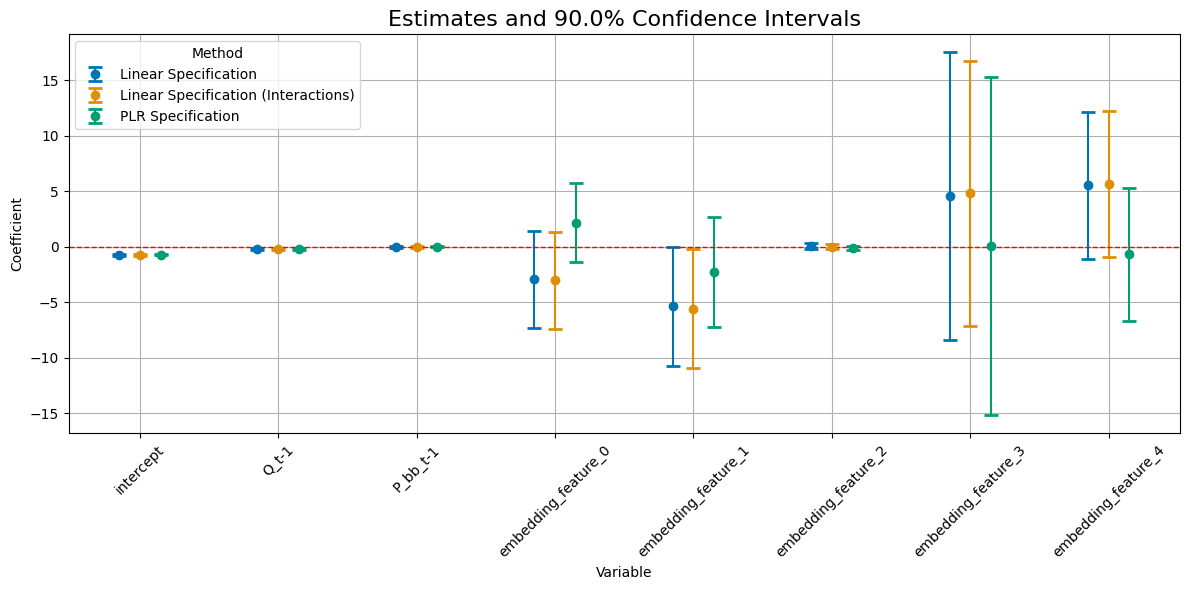

In [51]:
models = cate_summary_df["model"].unique()
variables = cate_summary_df["variable"].unique()
plt.figure(figsize=(12, 6))
bar_width = 0.15
x_positions = np.arange(len(variables))
for i, model in enumerate(models):
    df_model = cate_summary_df[cate_summary_df["model"] == model]
    if not df_model.empty:
        plt.errorbar(
            x_positions + i * bar_width,
            df_model["coef"],
            yerr=[
                df_model["coef"] - df_model["lower"],
                df_model["upper"] - df_model["coef"],
            ],
            fmt="o",
            label=model,
            capsize=5,
            capthick=2,
            ecolor=palette[i % len(palette)],
            color=palette[i % len(palette)],
            zorder=2,
        )
plt.xticks(x_positions + (len(models) - 1) * bar_width / 2, variables, rotation=45)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title(f"Estimates and {ci_level_name} Confidence Intervals", fontsize=16)
plt.xlabel("Variable")
plt.ylabel("Coefficient")
plt.legend(title="Method")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"cluster_and_level_cate_estimates.png"))
plt.show()

### $R^2$

In [52]:
alpha_x_lin = cate_models_polynomial["Linear Specification"].predict(df_basis)
alpha_x_lin_interactions = cate_models_polynomial["Linear Specification (Interactions)"].predict(df_basis)
alpha_x_plr = cate_models_polynomial["PLR Specification"].blp_model.predict(df_basis)


print("Linear Specification")
model_lin_emb = sm.OLS(alpha_x_lin, sm.add_constant(df_dynamic[embeddings])).fit()
model_lin_sim = sm.OLS(alpha_x_lin, sm.add_constant(df_dynamic[controls_similarities])).fit()
model_lin_lvl = sm.OLS(alpha_x_lin, sm.add_constant(df_dynamic[lag_1_vars])).fit()

print("Variance explained by embeddings: ", model_lin_emb.rsquared)
print("Variance explained by similarities: ", model_lin_sim.rsquared)
print("Variance explained by lagged variables: ", model_lin_lvl.rsquared)

print("Linear Specification with interactions")
model_lin_interactions_emb = sm.OLS(alpha_x_lin_interactions, sm.add_constant(df_dynamic[embeddings])).fit()
model_lin_interactions_sim = sm.OLS(alpha_x_lin_interactions, sm.add_constant(df_dynamic[controls_similarities])).fit()
model_lin_interactions_lvl = sm.OLS(alpha_x_lin_interactions, sm.add_constant(df_dynamic[lag_1_vars])).fit()
print("Variance explained by embeddings: ", model_lin_interactions_emb.rsquared)
print("Variance explained by similarities: ", model_lin_interactions_sim.rsquared)
print("Variance explained by lagged variables: ", model_lin_interactions_lvl.rsquared)

print("PLR Specification")
model_plr_emb = sm.OLS(alpha_x_plr, sm.add_constant(df_dynamic[embeddings])).fit()
model_plr_sim = sm.OLS(alpha_x_plr, sm.add_constant(df_dynamic[controls_similarities])).fit()
model_plr_lvl = sm.OLS(alpha_x_plr, sm.add_constant(df_dynamic[lag_1_vars])).fit()
print("Variance explained by embeddings: ", model_plr_emb.rsquared)
print("Variance explained by similarities: ", model_plr_sim.rsquared)
print("Variance explained by lagged variables: ", model_plr_lvl.rsquared)

Linear Specification
Variance explained by embeddings:  0.5240818040580875
Variance explained by similarities:  0.5240818040580875
Variance explained by lagged variables:  0.8919604356612649
Linear Specification with interactions
Variance explained by embeddings:  0.5083224230630934
Variance explained by similarities:  0.5083224230630934
Variance explained by lagged variables:  0.8839148297557479
PLR Specification
Variance explained by embeddings:  0.5816902331894653
Variance explained by similarities:  0.5816902331894653
Variance explained by lagged variables:  0.8492304978537046


## $\Chi^2$ Test

In [58]:
controls_similarities

['embedding_feature_0',
 'embedding_feature_1',
 'embedding_feature_2',
 'embedding_feature_3',
 'embedding_feature_4']

In [59]:
# select index with cluster similarity 
cluster_treatment_ids = [i for i, variable in enumerate(df_basis.columns) if variable in controls_similarities]
cluster_treatment_ids

[3, 4, 5, 6, 7]

In [60]:
lin_p_val = chi2_test(cate_models_polynomial['Linear Specification'], cluster_treatment_ids)
lin_interactions_p_val = chi2_test(
    cate_models_polynomial['Linear Specification (Interactions)'], cluster_treatment_ids
)
tab_dml_p_val = chi2_test(
    cate_models_polynomial['PLR Specification'], cluster_treatment_ids
)

print(f"Linear Specification p-value: {lin_p_val} (sample size: {len(df_dynamic)})")
print(f"Linear Specification (Interactions) p-value: {lin_interactions_p_val} (sample size: {len(df_dynamic)})")
print(f"PLR Specification p-value: {tab_dml_p_val} (sample size: {len(df_dynamic)})")

Linear Specification p-value: 0.5257756443690123 (sample size: 38041)
Linear Specification (Interactions) p-value: 0.44271238363002163 (sample size: 38041)
PLR Specification p-value: 0.006919882216163575 (sample size: 38041)


In [61]:
het_ids = [1, 2, 3, 4, 5, 6]

lin_p_val = chi2_test(cate_models_polynomial['Linear Specification'], het_ids)
lin_interactions_p_val = chi2_test(
    cate_models_polynomial['Linear Specification (Interactions)'], het_ids
)
tab_dml_p_val = chi2_test(
    cate_models_polynomial['PLR Specification'], het_ids
)

print(f"Linear Specification p-value: {lin_p_val} (sample size: {len(df_dynamic)})")
print(f"Linear Specification (Interactions) p-value: {lin_interactions_p_val} (sample size: {len(df_dynamic)})")
print(f"PLR Specification p-value: {tab_dml_p_val} (sample size: {len(df_dynamic)})")

Linear Specification p-value: 4.7006788242986985e-05 (sample size: 38041)
Linear Specification (Interactions) p-value: 2.933794107384813e-05 (sample size: 38041)
PLR Specification p-value: 1.596967134631644e-05 (sample size: 38041)


## Sorted Effects

In [62]:
treatment_ids = [0, 1, 2] + cluster_treatment_ids
df_basis_sorted = df_basis.iloc[:, treatment_ids]#.join(df_dynamic[["ASIN", "date"]])

In [63]:
df_basis_sorted

,intercept,Q_t-1,P_bb_t-1,embedding_feature_0,embedding_feature_1,embedding_feature_2,embedding_feature_3,embedding_feature_4
0,1.0,0.305280,0.463601,0.031347,0.014870,0.081420,-0.000508,0.035535
1,1.0,0.272505,0.653600,0.033163,0.016355,0.068650,-0.000415,0.037952
2,1.0,0.036240,0.687961,0.033476,0.016584,0.066604,-0.000398,0.038318
3,1.0,0.025283,0.636881,0.032902,0.015976,0.071955,-0.000435,0.037443
4,1.0,-0.051370,0.556816,0.036109,0.018395,0.051093,-0.000275,0.041751
...,...,...,...,...,...,...,...,...
38036,1.0,0.009068,0.478593,-0.112833,-0.064694,-0.003841,-0.002858,-0.119795
38037,1.0,-0.393270,-0.753352,0.055684,0.001136,0.513121,-0.001570,0.045923
38038,1.0,-0.277916,-0.753352,0.076137,0.012490,0.470709,-0.001177,0.066782
38039,1.0,1.267533,-1.535804,0.225693,0.099156,0.168491,0.003325,0.185072


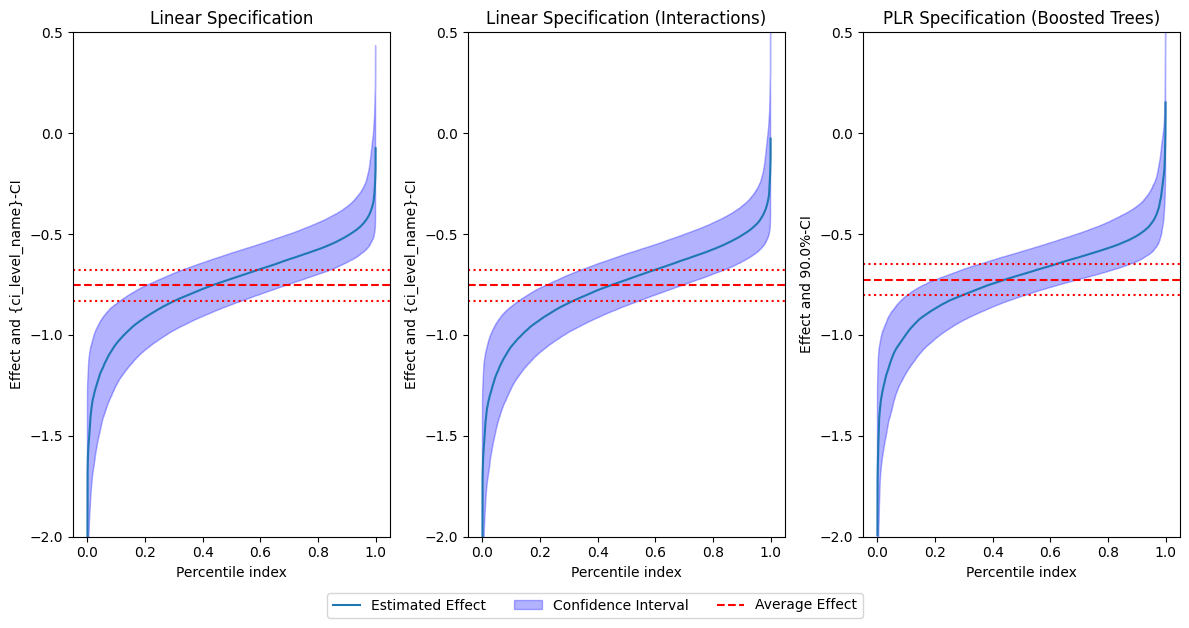

In [64]:
uniform_ci=False

plt.rcParams["figure.figsize"] = (
    15.0,
    7.5,
)  # Adjusted the figure size for side-by-side plots
# Determine the number of models to plot
num_plots = 1
# Create subplots with cate_vars as rows and models as columns
fig, axs = plt.subplots(nrows=num_plots, ncols=3, figsize=(12, 6 * num_plots))
# If there's only one model, axs won't be a list, so wrap it in a list
if num_plots == 1:
    axs = np.array([axs, axs])  # Create a 2-column array


# Linear model
df_lin_ci_pointwise = predict_cate(
    cate_models_polynomial["Linear Specification"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
)
df_lin_ci_pointwise_sorted = df_lin_ci_pointwise.apply(
    lambda x: x.sort_values().values, axis=0
)
df_lin_ci_uniform = predict_cate(
    cate_models_polynomial["Linear Specification"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
    joint=True,
)
df_lin_ci_uniform_sorted = df_lin_ci_uniform.apply(
    lambda x: x.sort_values().values, axis=0
)
lm_intercept = cate_models_polynomial["Linear Specification"].params["intercept"]
lm_intercept_ci = cate_models_polynomial["Linear Specification"].conf_int().loc["intercept"]

# Tabular DML model
df_tab_dml_ci_pointwise = predict_cate(
    cate_models_polynomial["Linear Specification (Interactions)"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
)
df_tab_dml_ci_pointwise_sorted = df_tab_dml_ci_pointwise.apply(
    lambda x: x.sort_values().values, axis=0
)
df_tab_dml_ci_joint = predict_cate(
    cate_models_polynomial["Linear Specification (Interactions)"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
    joint=True,
)
df_tab_dml_ci_joint_sorted = df_tab_dml_ci_joint.apply(
    lambda x: x.sort_values().values, axis=0
)

tab_dml_intercept = cate_models_polynomial["Linear Specification"].params["intercept"]
tab_dml_intercept_ci = cate_models_polynomial["Linear Specification"].conf_int().loc["intercept"]

# PLR Model
df_deep_dml_ci_pointwise = predict_cate(
    cate_models_polynomial['PLR Specification'],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
)
df_deep_dml_ci_pointwise_sorted = df_deep_dml_ci_pointwise.apply(
    lambda x: x.sort_values().values, axis=0
)
df_deep_dml_ci_joint = predict_cate(
    cate_models_polynomial['PLR Specification'],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
    joint=True,
)
df_deep_dml_ci_joint_sorted = df_deep_dml_ci_joint.apply(
    lambda x: x.sort_values().values, axis=0
)
deep_dml_intercept = cate_models_polynomial['PLR Specification'].blp_model.params[
    "intercept"
]
deep_dml_intercept_ci = (
    cate_models_polynomial['PLR Specification'].blp_model.conf_int().loc["intercept"]
)

# Calculate the y-axis limits for this row
y_min = min(
    df_lin_ci_pointwise[ci_names[0]].min(),
    df_lin_ci_uniform[ci_names[0]].min(),
    df_tab_dml_ci_pointwise[ci_names[0]].min(),
    df_tab_dml_ci_joint[ci_names[0]].min(),
    df_deep_dml_ci_pointwise[ci_names[0]].min(),
    df_deep_dml_ci_joint[ci_names[0]].min(),
)
y_max = max(
    df_lin_ci_pointwise[ci_names[1]].max(),
    df_lin_ci_uniform[ci_names[1]].max(),
    df_tab_dml_ci_pointwise[ci_names[1]].max(),
    df_tab_dml_ci_joint[ci_names[1]].max(),
    df_deep_dml_ci_pointwise[ci_names[1]].max(),
    df_deep_dml_ci_joint[ci_names[1]].max(),
)

# further adjust y-axis limits
y_min = max(y_min, -2)
y_max = min(y_max, 0.5)
percentiles_idx = np.linspace(0, 1, df_dynamic.shape[0])
percentiles_idx_full = np.linspace(0, 1, df_dynamic.shape[0])
# Plot on the first column
i = 0
ax0 = axs[i, 0]
ax0.plot(
    percentiles_idx_full, df_lin_ci_pointwise_sorted["effect"], label="Estimated Effect"
)
ax0.fill_between(
    percentiles_idx_full,
    df_lin_ci_pointwise_sorted[ci_names[0]],
    df_lin_ci_pointwise_sorted[ci_names[1]],
    color="b",
    alpha=0.3,
    label="Confidence Interval",
)
if uniform_ci:
    ax0.fill_between(
        percentiles_idx_full,
        df_lin_ci_uniform_sorted[ci_names[0]],
        df_lin_ci_uniform_sorted[ci_names[1]],
        color="b",
        alpha=0.1,
        label="Uniform Confidence Interval",
    )
ax0.axhline(y=lm_intercept, color="r", linestyle="--", label="ATE")
ax0.axhline(y=lm_intercept_ci[0], color="r", linestyle="dotted")
ax0.axhline(y=lm_intercept_ci[1], color="r", linestyle="dotted")
ax0.set_title("Linear Specification")
ax0.set_xlabel("Percentile index")
ax0.set_ylabel("Effect and {ci_level_name}-CI")
ax0.set_ylim(y_min, y_max)
ax1 = axs[i, 1]
ax1.plot(
    percentiles_idx_full,
    df_tab_dml_ci_pointwise_sorted["effect"],
    label="Estimated Effect",
)
ax1.fill_between(
    percentiles_idx_full,
    df_tab_dml_ci_pointwise_sorted[ci_names[0]],
    df_tab_dml_ci_pointwise_sorted[ci_names[1]],
    color="b",
    alpha=0.3,
    label="Confidence Interval",
)
if uniform_ci:
    ax1.fill_between(
        percentiles_idx_full,
        df_tab_dml_ci_joint_sorted[ci_names[0]],
        df_tab_dml_ci_joint_sorted[ci_names[1]],
        color="b",
        alpha=0.1,
        label="Uniform Confidence Interval",
    )
ax1.axhline(y=tab_dml_intercept, color="r", linestyle="--", label="Average Effect")
ax1.axhline(y=tab_dml_intercept_ci[0], color="r", linestyle="dotted")
ax1.axhline(y=tab_dml_intercept_ci[1], color="r", linestyle="dotted")
ax1.set_title("Linear Specification (Interactions)")
ax1.set_xlabel("Percentile index")
ax1.set_ylabel("Effect and {ci_level_name}-CI")
ax1.set_ylim(y_min, y_max)

ax2 = axs[i, 2]
ax2.plot(
    percentiles_idx_full,
    df_deep_dml_ci_pointwise_sorted["effect"],
    label="Estimated Effect",
)
ax2.fill_between(
    percentiles_idx_full,
    df_deep_dml_ci_pointwise_sorted[ci_names[0]],
    df_deep_dml_ci_pointwise_sorted[ci_names[1]],
    color="b",
    alpha=0.3,
    label="Confidence Interval",
)
if uniform_ci:
    ax2.fill_between(
        percentiles_idx_full,
        df_deep_dml_ci_joint_sorted[ci_names[0]],
        df_deep_dml_ci_joint_sorted[ci_names[1]],
        color="b",
        alpha=0.1,
        label="Uniform Confidence Interval",
    )
ax2.axhline(y=deep_dml_intercept, color="r", linestyle="--", label="Average Effect")
ax2.axhline(y=deep_dml_intercept_ci[0], color="r", linestyle="dotted")
ax2.axhline(y=deep_dml_intercept_ci[1], color="r", linestyle="dotted")

ax2.set_title("PLR Specification (Boosted Trees)")
ax2.set_xlabel("Percentile index")
ax2.set_ylabel(f"Effect and {ci_level_name}-CI")
ax2.set_ylim(y_min, y_max)

# Create a single legend for all plots and place it at the lower center
handles, labels = axs[
    -1, 1
].get_legend_handles_labels()  # Collect handles and labels from the last subplot
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=4)
# Adjust layout to make space for the legend
plt.tight_layout(rect=[0, 0.0, 1, 1])  # Leave space at the bottom for the legend

# Save the figure with tight bounding box to include the legend
plt.savefig(
    os.path.join(output_dir, "cluster_sorted_effects.png"), 
    bbox_inches="tight"
)
plt.show()

In [65]:
quantiles = np.arange(start=0.01, stop=1, step=0.01)
m = len(quantiles)
pes = df_tab_dml_ci_pointwise["effect"]
spes = df_tab_dml_ci_pointwise["effect"].quantile(quantiles).values
spes

array([-1.4465945 , -1.33474719, -1.27979177, -1.23171181, -1.19103326,
       -1.15691923, -1.12720846, -1.1025242 , -1.07846977, -1.05759606,
       -1.04041914, -1.02417168, -1.0098427 , -0.99479919, -0.98072446,
       -0.96830414, -0.9557768 , -0.94511947, -0.93465433, -0.92513978,
       -0.91469425, -0.9055755 , -0.89692822, -0.88777245, -0.87888257,
       -0.87071128, -0.86276466, -0.85574404, -0.84841447, -0.84113495,
       -0.83428809, -0.82775357, -0.82132848, -0.81495038, -0.80892596,
       -0.80318462, -0.79677526, -0.79056446, -0.7843432 , -0.77794118,
       -0.7724283 , -0.76733302, -0.76183974, -0.75664104, -0.75142426,
       -0.74629661, -0.74152186, -0.73665056, -0.73157363, -0.72659668,
       -0.72137598, -0.71635835, -0.71122498, -0.70612536, -0.70114355,
       -0.69602172, -0.69130227, -0.68632329, -0.68158615, -0.67659115,
       -0.67207153, -0.66690003, -0.66258612, -0.65766181, -0.65238464,
       -0.64747817, -0.64278299, -0.6375168 , -0.63223217, -0.62